In [23]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

In [24]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

tickers = ["TSLA", "BND", "SPY"]

start_date = "2015-01-01"
end_date = "2026-07-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by="ticker",
    auto_adjust=False,
    threads=False,
    progress=False
)

data.head()

Ticker           TSLA                                                        \
Price            Open       High        Low      Close  Adj Close    Volume   
Date                                                                          
2015-01-02  14.858000  14.883333  14.217333  14.620667  14.620667  71466000   
2015-01-05  14.303333  14.433333  13.810667  14.006000  14.006000  80527500   
2015-01-06  14.004000  14.280000  13.614000  14.085333  14.085333  93928500   
2015-01-07  14.223333  14.318667  13.985333  14.063333  14.063333  44526000   
2015-01-08  14.187333  14.253333  14.000667  14.041333  14.041333  51637500   

Ticker            BND                                                       \
Price            Open       High        Low      Close  Adj Close   Volume   
Date                                                                         
2015-01-02  82.430000  82.690002  82.419998  82.650002  59.205685  2218800   
2015-01-05  82.739998  82.919998  82.699997  82.889999  59.377590  5820100   
2015-01-06  83.029999  83.379997  83.029999  83.129997  59.549522  3887600   
2015-01-07  83.139999  83.279999  83.050003  83.180000  59.585300  2433400   
2015-01-08  83.110001  83.110001  82.970001  83.050003  59.492199  1873400   

Ticker             SPY                                                  \
Price             Open        High         Low       Close   Adj Close   
Date                                                                     
2015-01-02  206.380005  206.880005  204.179993  205.429993  169.687851   
2015-01-05  204.169998  204.369995  201.350006  201.720001  166.623306   
2015-01-06  202.089996  202.720001  198.860001  199.820007  165.053925   
2015-01-07  201.419998  202.720001  200.880005  202.309998  167.110672   
2015-01-08  204.009995  206.160004  203.990005  205.899994  170.076065   

Ticker                 
Price          Volume  
Date                   
2015-01-02  121465900  
2015-01-05  169632600  
2015-01-06  209151400  
2015-01-07  125346700  
2015-01-08  147217800

In [25]:
for ticker in tickers:
    ticker_data = data[ticker]
    ticker_data.to_csv(f"../data/raw/{ticker}_raw.csv")

In [26]:
for ticker in tickers:
    print(f"\n--- {ticker} ---")
    df = data[ticker]
    print(df.head())
    print(df.info())
    print(df.describe())


--- TSLA ---
Price            Open       High        Low      Close  Adj Close    Volume
Date                                                                       
2015-01-02  14.858000  14.883333  14.217333  14.620667  14.620667  71466000
2015-01-05  14.303333  14.433333  13.810667  14.006000  14.006000  80527500
2015-01-06  14.004000  14.280000  13.614000  14.085333  14.085333  93928500
2015-01-07  14.223333  14.318667  13.985333  14.063333  14.063333  44526000
2015-01-08  14.187333  14.253333  14.000667  14.041333  14.041333  51637500
<class 'pandas.DataFrame'>
DatetimeIndex: 2889 entries, 2015-01-02 to 2026-06-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2889 non-null   float64
 1   High       2889 non-null   float64
 2   Low        2889 non-null   float64
 3   Close      2889 non-null   float64
 4   Adj Close  2889 non-null   float64
 5   Volume     2889 non-null   int64  
dtypes: float64(5), i

In [27]:
for ticker in tickers:
    print(f"\nMissing values for {ticker}:")
    print(data[ticker].isnull().sum())


Missing values for TSLA:
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values for BND:
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values for SPY:
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [28]:
cleaned_data = {}

for ticker in tickers:
    cleaned_data[ticker] = data[ticker].copy()
    cleaned_data[ticker] = cleaned_data[ticker].dropna()

print("Cleaned data created successfully.")

Cleaned data created successfully.


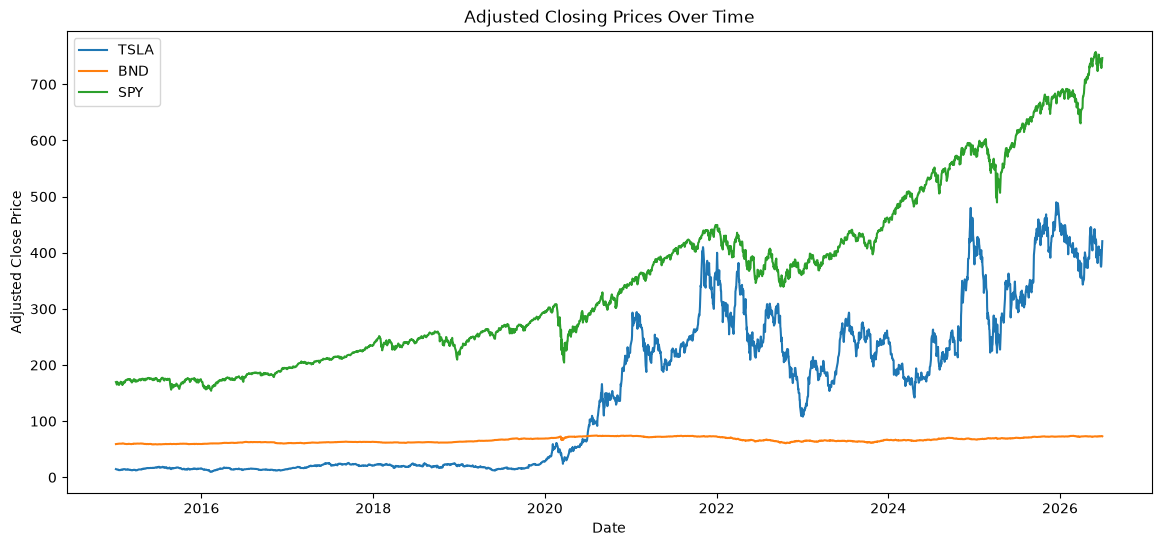

In [29]:
plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(cleaned_data[ticker].index, cleaned_data[ticker]["Adj Close"], label=ticker)

plt.title("Adjusted Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.show()

In [30]:
returns = {}

for ticker in tickers:
    df = cleaned_data[ticker].copy()
    df["Daily_Return"] = df["Adj Close"].pct_change()
    df = df.dropna()
    returns[ticker] = df

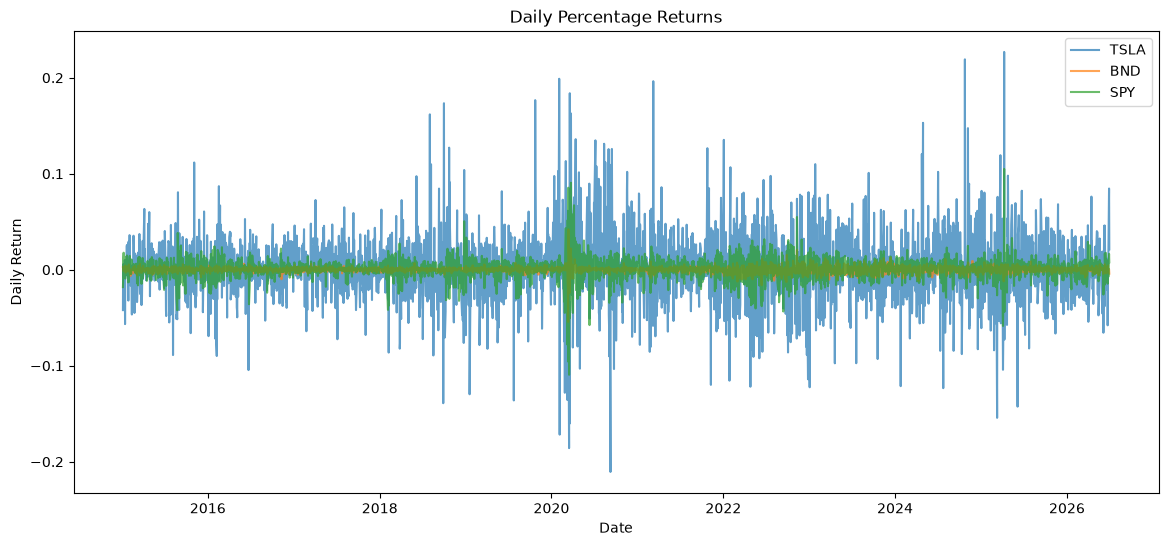

In [31]:
plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(returns[ticker].index, returns[ticker]["Daily_Return"], label=ticker, alpha=0.7)

plt.title("Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()

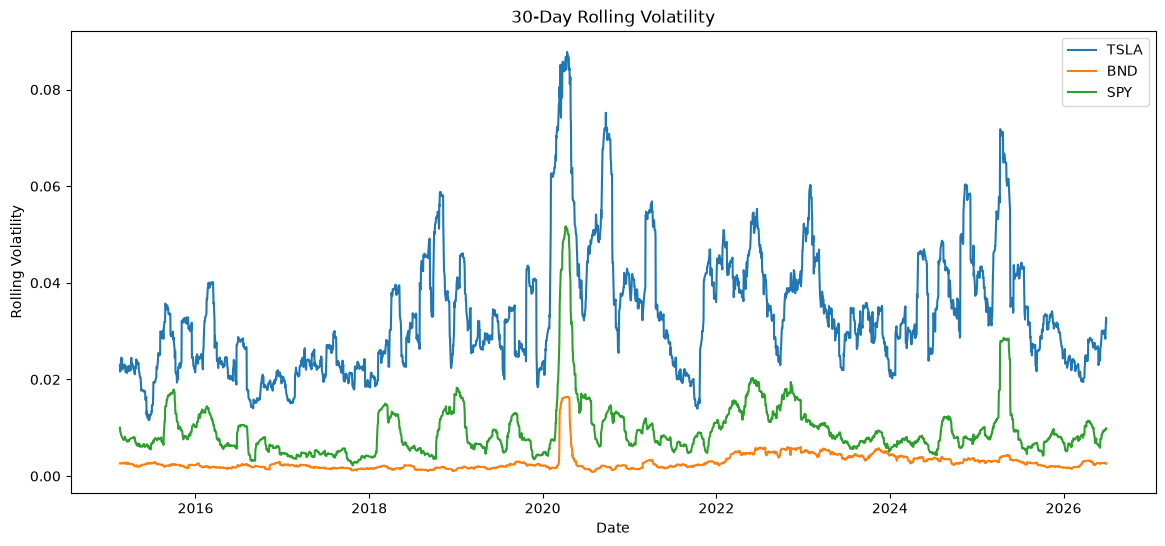

In [32]:
window = 30

plt.figure(figsize=(14, 6))

for ticker in tickers:
    returns[ticker]["Rolling_Volatility"] = returns[ticker]["Daily_Return"].rolling(window).std()
    plt.plot(returns[ticker].index, returns[ticker]["Rolling_Volatility"], label=ticker)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.legend()
plt.show()

In [33]:
for ticker in tickers:
    df = returns[ticker]
    mean_return = df["Daily_Return"].mean()
    std_return = df["Daily_Return"].std()

    outliers = df[
        (df["Daily_Return"] > mean_return + 3 * std_return) |
        (df["Daily_Return"] < mean_return - 3 * std_return)
    ]

    print(f"{ticker} outlier days: {len(outliers)}")
    display(outliers[["Adj Close", "Daily_Return"]].head())

TSLA outlier days: 46


Price,Adj Close,Daily_Return
Date,,
2015-11-04,15.442000,0.111735
2018-08-02,23.302668,0.161880
2018-08-07,25.304667,0.109886
2018-09-28,17.651333,-0.139015
2018-10-01,20.713333,0.173471


BND outlier days: 33


Price,Adj Close,Daily_Return
Date,,
2020-03-10,71.471695,-0.013444
2020-03-11,70.118034,-0.018940
2020-03-12,66.304672,-0.054385
2020-03-13,69.102776,0.042201
2020-03-16,69.829132,0.010511


SPY outlier days: 39


Price,Adj Close,Daily_Return
Date,,
2015-08-24,157.992966,-0.042107
2015-08-26,162.128296,0.038394
2016-06-24,173.122559,-0.035909
2018-02-05,231.705292,-0.041822
2018-02-08,226.174438,-0.037509


In [34]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")

    if result[1] < 0.05:
        print("Result: Stationary")
    else:
        print("Result: Non-stationary")
    print("\n")

In [35]:
for ticker in tickers:
    adf_test(cleaned_data[ticker]["Adj Close"], f"{ticker} Adjusted Close Price")

ADF Test for TSLA Adjusted Close Price
ADF Statistic: -1.0191265386268278
p-value: 0.7462245736824926
Result: Non-stationary


ADF Test for BND Adjusted Close Price
ADF Statistic: -1.0798539956678606
p-value: 0.7230386742396269
Result: Non-stationary


ADF Test for SPY Adjusted Close Price
ADF Statistic: 1.3894643443226578
p-value: 0.997065750595665
Result: Non-stationary




In [36]:
for ticker in tickers:
    adf_test(returns[ticker]["Daily_Return"], f"{ticker} Daily Returns")

ADF Test for TSLA Daily Returns
ADF Statistic: -54.00424338310577
p-value: 0.0
Result: Stationary


ADF Test for BND Daily Returns
ADF Statistic: -15.239064999963187
p-value: 5.193291634190765e-28
Result: Stationary


ADF Test for SPY Daily Returns
ADF Statistic: -17.585052057274364
p-value: 3.989700982012779e-30
Result: Stationary




In [37]:
risk_metrics = []

for ticker in tickers:
    daily_returns = returns[ticker]["Daily_Return"]

    var_95 = np.percentile(daily_returns, 5)
    avg_daily_return = daily_returns.mean()
    daily_volatility = daily_returns.std()

    annual_return = avg_daily_return * 252
    annual_volatility = daily_volatility * np.sqrt(252)

    risk_free_rate = 0.02
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    risk_metrics.append({
        "Ticker": ticker,
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "VaR 95%": var_95,
        "Sharpe Ratio": sharpe_ratio
    })

risk_df = pd.DataFrame(risk_metrics)
risk_df

,Ticker,Annual Return,Annual Volatility,VaR 95%,Sharpe Ratio
0,TSLA,0.455938,0.571704,-0.051657,0.762523
1,BND,0.019888,0.053128,-0.004756,-0.002105
2,SPY,0.144950,0.176529,-0.016646,0.707814


In [38]:
risk_df.to_csv("../data/processed/risk_metrics.csv", index=False)

In [39]:
import os

os.makedirs("data/processed", exist_ok=True)

for ticker in tickers:
    data[ticker].dropna().to_csv(f"data/processed/{ticker}_cleaned.csv")

print("Cleaned CSV files saved successfully.")

Cleaned CSV files saved successfully.


In [40]:
import os

os.makedirs("data/processed", exist_ok=True)

for ticker in tickers:
    data[ticker].dropna().to_csv(f"data/processed/{ticker}_cleaned.csv")

print("Saved cleaned files:")
print(os.listdir("data/processed"))

Saved cleaned files:
['TSLA_cleaned.csv', 'BND_cleaned.csv', 'SPY_cleaned.csv']
